In [1]:
#what is data augmentation?
# Data augmentation is a technique used in machine learning and deep learning to increase the diversity of training data without actually collecting new data. It involves applying various transformations to the existing data, such as rotation, scaling, flipping, cropping, and adding noise. This helps to improve the generalization ability of models by exposing them to a wider range of variations in the input data. Data augmentation is commonly used in image processing tasks but can also be applied to other types of data, such as text and audio.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential 
#import optimizer and loss function
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
train_generator = ImageDataGenerator(rescale=1./255, 
                                   rotation_range=20, 
                                   width_shift_range=0.2, 
                                   height_shift_range=0.2, 
                                   shear_range=0.2, 
                                   zoom_range=0.2, 
                                   horizontal_flip=True,
                                   fill_mode='nearest')
train_data = train_generator.flow_from_directory('C:\\Users\\Acer\\academics\\deep_learning\\Datasets\\brain_alzheimer\\Combined Dataset\\train',
                                                 target_size=(224, 224),
                                                 batch_size=32,
                                                 class_mode='categorical')                               

Found 10240 images belonging to 4 classes.


In [4]:
test_generator = ImageDataGenerator(rescale=1./255)
test_data = test_generator.flow_from_directory('C:\\Users\\Acer\\academics\\deep_learning\\Datasets\\brain_alzheimer\\Combined Dataset\\test',
                                                 target_size=(224, 224),
                                                 batch_size=32,
                                                 class_mode='categorical')

Found 1279 images belonging to 4 classes.


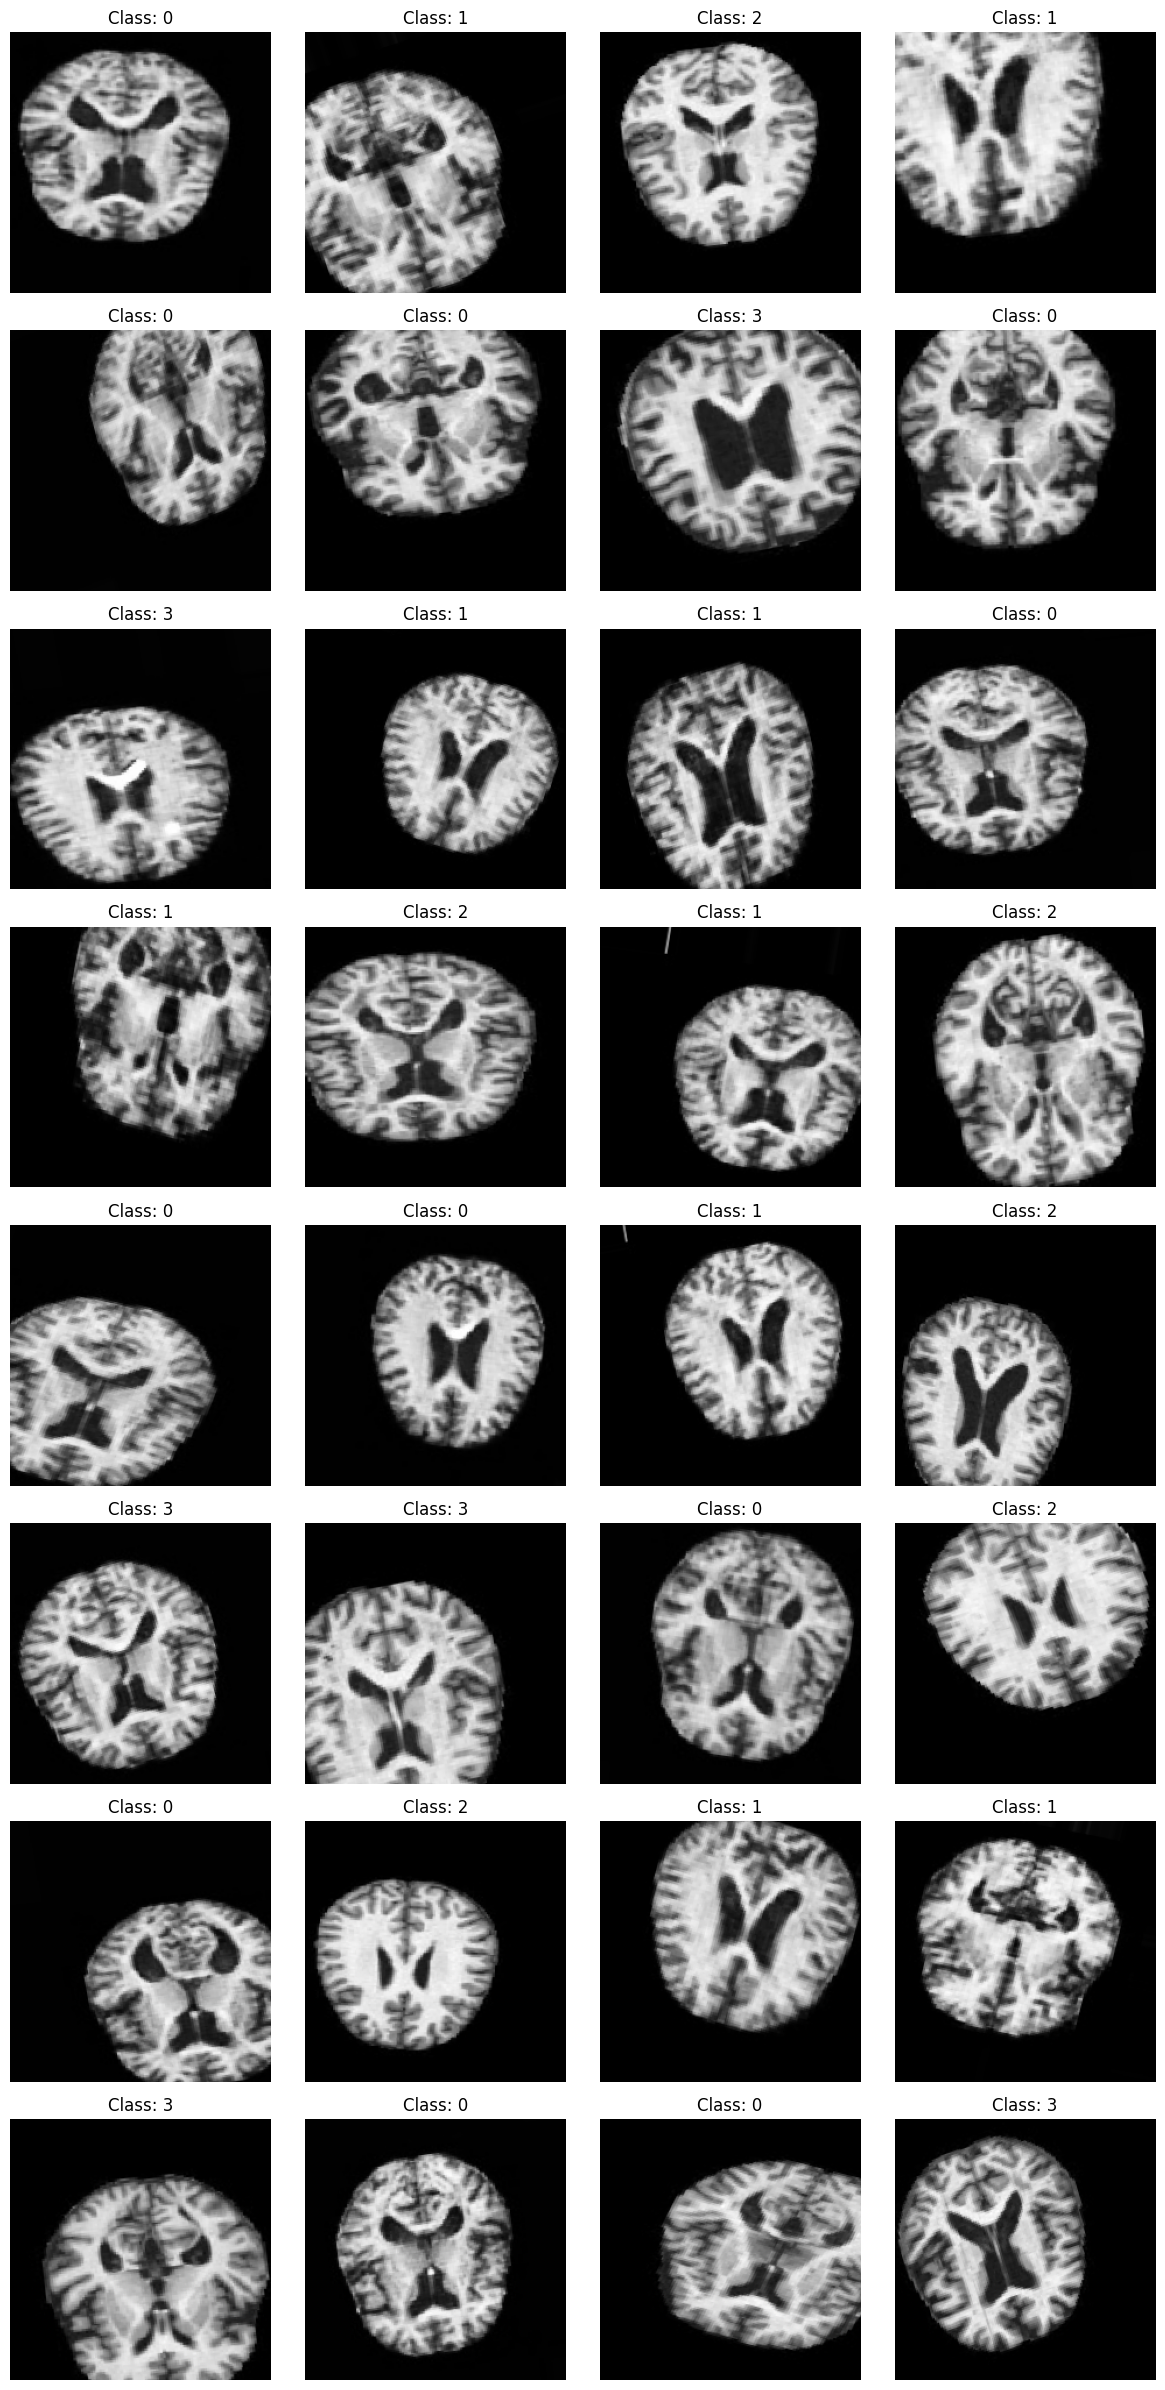

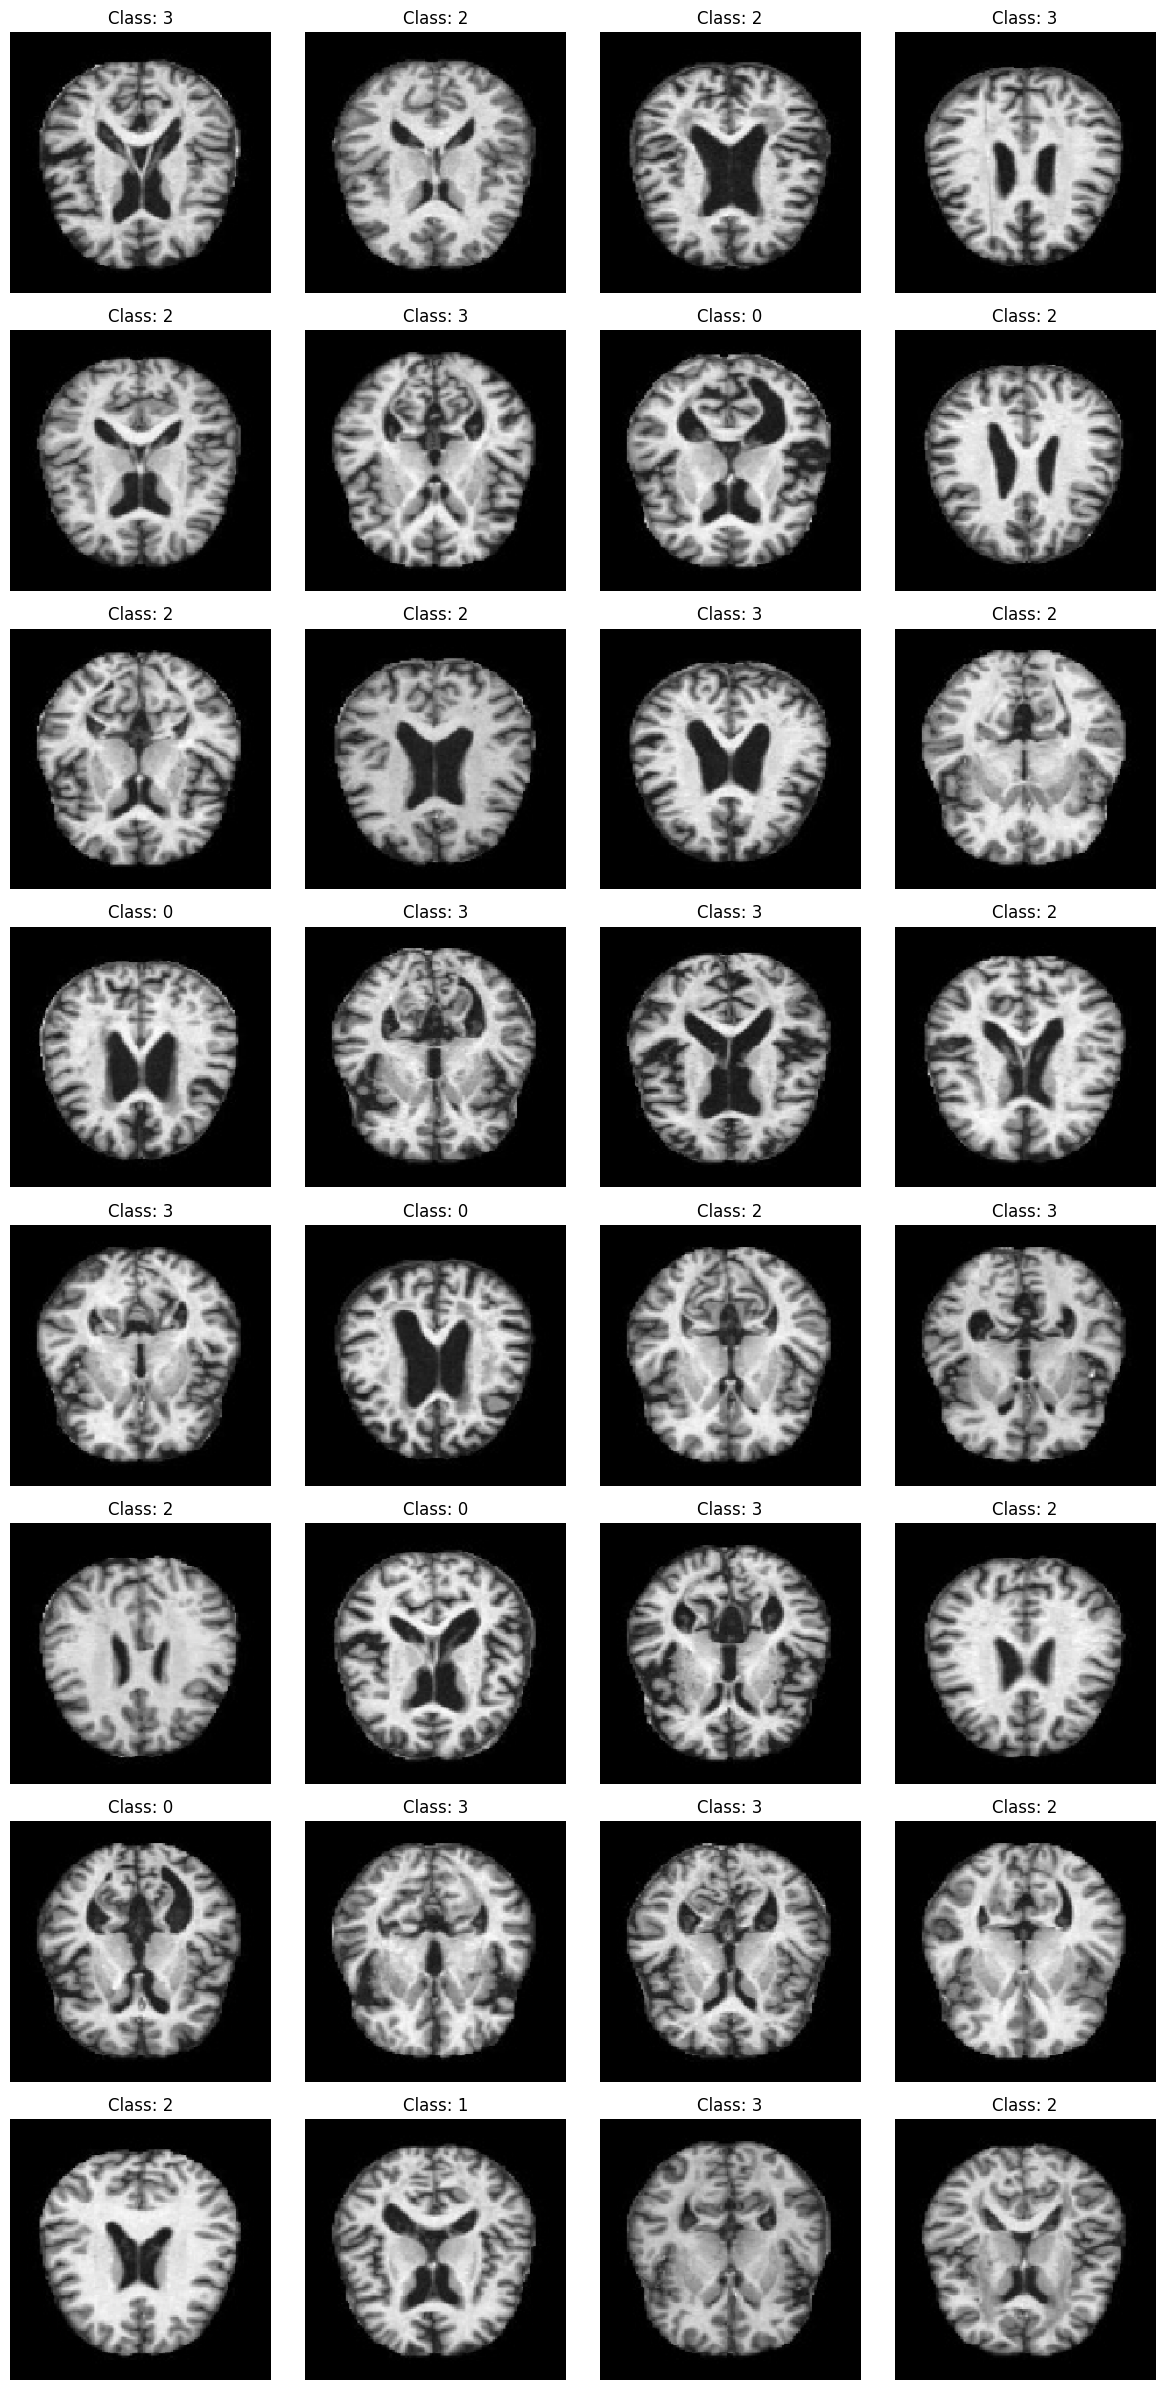

In [5]:
#@title Plotting an images
import math
# Function to plot images
def plot_images(images, labels):
    num_images = images.shape[0]
    num_rows = int(math.ceil(num_images / 4))
    fig, axes = plt.subplots(num_rows, 4, figsize=(12, 3 * num_rows))
    for i in range(num_images):
        row = i // 4
        col = i % 4
        axes[row, col].imshow(images[i])
        axes[row, col].set_title(f"Class: {np.argmax(labels[i])}")
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()


# Get a batch of training images and labels
train_images, train_labels = next(train_data)

# Get a batch of testing images and labels
test_images, test_labels = next(test_data)

# Plot a few images from the training and testing data
import matplotlib.pyplot as plt
import numpy as np
plot_images(train_images, train_labels)
plot_images(test_images, test_labels)

In [6]:
#CNN 
#conv---pooling---conv---pooling---flatten---dense---output

model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(224,224,3),strides=1, padding='same'),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(128, (3, 3), activation='relu'),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    Conv2D(256, (3, 3), activation='relu'),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(512, (3, 3), activation='relu'),
    Conv2D(512, (3, 3), activation='relu'),
    Conv2D(512, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(512, (3, 3), activation='relu'),
    Conv2D(512, (3, 3), activation='relu'),
    Conv2D(512, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(4096, activation='softmax'),
    Dense(4096, activation='softmax'),
    Dense(4, activation='softmax')
])

c:\Users\Acer\academics\deep_learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#optimizers and loss function
model_compile = model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
History = model.fit(train_data, epochs=50, validation_data=test_data, verbose=1)

Epoch 1/50
204/320 ━━━━━━━━━━━━━━━━━━━━ 26:09 14s/step - accuracy: 0.2427 - loss: 1.3864

KeyboardInterrupt: 

In [ ]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


VGG16

In [16]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model


In [9]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


In [ ]:
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

In [13]:
# Add custom layers on top of the base model
num_classes = 4
x = Flatten()(base_model.output)
x1 = Dense(4096, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions = Dense(num_classes, activation='softmax')(x2)

In [17]:
#create the final model
model = Model(inputs=base_model.input, outputs=predictions)

In [18]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         4,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,580,236 (463.79 MB)

 Trainable params: 106,865,548 (407.66 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [19]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
from tensorflow.keras.callbacks import TensorBoard

model.fit(train_data, epochs=5, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10, callbacks=[TensorBoard(log_dir='./logs')])
#in tensorboard log_dir is the directory where the logs will be saved. You can specify any directory you want, but it's common to use a directory called 'logs' in the current working directory. The logs will be saved in a subdirectory of 'logs' with a name that includes the date and time of the training run.
#callback means that we can stop the training if the validation loss does not improve for a certain number of epochs, or we can save the best model based on validation accuracy. This helps to prevent overfitting and ensures that we get the best possible performance from our model.

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 316s 6s/step - accuracy: 0.3119 - loss: 4.5397 - val_accuracy: 0.5156 - val_loss: 1.1220
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 316s 6s/step - accuracy: 0.4894 - loss: 1.1517 - val_accuracy: 0.4812 - val_loss: 0.9665
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 326s 7s/step - accuracy: 0.5612 - loss: 0.9580 - val_accuracy: 0.5000 - val_loss: 0.9195
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 315s 6s/step - accuracy: 0.5813 - loss: 0.8890 - val_accuracy: 0.5250 - val_loss: 0.9847
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 311s 6s/step - accuracy: 0.5706 - loss: 0.9332 - val_accuracy: 0.5094 - val_loss: 0.9773


In [26]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 182s 5s/step - accuracy: 0.5051 - loss: 0.9741
Test Loss: 0.9740648865699768
Test Accuracy: 0.5050820708274841


In [1]:
# train 4 models inceptionv3, resnet50, efficientnet, mobilenetv2 and compare their performance 
#acc loss val_acc val_loss 
#epoch same......

In [ ]:
from tensorflow.keras.applications import InceptionV3, ResNet50, EfficientNetB0, MobileNetV2


InceptionV3

In [ ]:
#first inceptionv3
base_model_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_inception.layers:
    layer.trainable = False
x = Flatten()(base_model_inception.output)
x1 = Dense(4096, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions_inception = Dense(num_classes, activation='softmax')(x2)
model_inception = Model(inputs=base_model_inception.input, outputs=predictions_inception)
model_inception.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_inception = model_inception.fit(train_data, epochs=5, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10)
loss_inception, accuracy_inception = model_inception.evaluate(test_data)
print(f"InceptionV3 Test Loss: {loss_inception}")
print(f"InceptionV3 Test Accuracy: {accuracy_inception}")

Resnet50

In [ ]:
#Resnet50
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_resnet.layers:
    layer.trainable = False
x = Flatten()(base_model_resnet.output)
x1 = Dense(4096, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions_resnet = Dense(num_classes, activation='softmax')(x2)
model_resnet = Model(inputs=base_model_resnet.input, outputs=predictions_resnet)
model_resnet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_resnet = model_resnet.fit(train_data, epochs=5, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10)
loss_resnet, accuracy_resnet = model_resnet.evaluate(test_data)
print(f"ResNet50 Test Loss: {loss_resnet}")
print(f"ResNet50 Test Accuracy: {accuracy_resnet}")


EfficientNetB0

In [ ]:
#EfficientNetB0
base_model_efficientnet = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_efficientnet.layers:
    layer.trainable = False
x = Flatten()(base_model_efficientnet.output)
x1 = Dense(4096, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions_efficientnet = Dense(num_classes, activation='softmax')(x2)
model_efficientnet = Model(inputs=base_model_efficientnet.input, outputs=predictions_efficientnet)
model_efficientnet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_efficientnet = model_efficientnet.fit(train_data, epochs=5, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10)
loss_efficientnet, accuracy_efficientnet = model_efficientnet.evaluate(test_data)
print(f"EfficientNetB0 Test Loss: {loss_efficientnet}")
print(f"EfficientNetB0 Test Accuracy: {accuracy_efficientnet}")

MobileNetV2

In [ ]:
#MobileNetV2
base_model_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_mobilenet.layers:
    layer.trainable = False
x = Flatten()(base_model_mobilenet.output)
x1 = Dense(4096, activation='relu')(x)
x2 = Dense(1000, activation='relu')(x1)
predictions_mobilenet = Dense(num_classes, activation='softmax')(x2)
model_mobilenet = Model(inputs=base_model_mobilenet.input, outputs=predictions_mobilenet)
model_mobilenet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_mobilenet = model_mobilenet.fit(train_data, epochs=5, validation_data=test_data, verbose=1, steps_per_epoch=50, validation_steps=10)
loss_mobilenet, accuracy_mobilenet = model_mobilenet.evaluate(test_data)
print(f"MobileNetV2 Test Loss: {loss_mobilenet}")
print(f"MobileNetV2 Test Accuracy: {accuracy_mobilenet}")

compare all 4

In [ ]:
#compare the performance of the models
print(f"InceptionV3 Test Accuracy: {accuracy_inception}")
print(f"ResNet50 Test Accuracy: {accuracy_resnet}")
print(f"EfficientNetB0 Test Accuracy: {accuracy_efficientnet}")
print(f"MobileNetV2 Test Accuracy: {accuracy_mobilenet}")
print(f"InceptionV3 Test Loss: {loss_inception}")
print(f"ResNet50 Test Loss: {loss_resnet}")
print(f"EfficientNetB0 Test Loss: {loss_efficientnet}")
print(f"MobileNetV2 Test Loss: {loss_mobilenet}")

In [ ]:
#compare all 4 using graphs
import matplotlib.pyplot as plt
models = ['InceptionV3', 'ResNet50', 'EfficientNetB0', 'MobileNetV2']
accuracies = [accuracy_inception, accuracy_resnet, accuracy_efficientnet, accuracy_mobilenet]
losses = [loss_inception, loss_resnet, loss_efficientnet, loss_mobilenet]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'red'])
plt.title('Test Accuracy of Models')
plt.subplot(1, 2, 2)
plt.bar(models, losses, color=['blue', 'orange', 'green', 'red'])
plt.title('Test Loss of Models')
plt.show()